
"""
📌 MODEL COMPARISON (AUTO-GENERATION)

This notebook:
✔ Loads all model histories
✔ Generates comparison graphs
✔ Saves results automatically
"""

In [2]:
# %%
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries loaded")

✅ Libraries loaded


In [3]:
# %%
os.makedirs('../results/graphs', exist_ok=True)
print("✅ Graph folder ready")

✅ Graph folder ready


In [4]:
# %%
with open('../results/lstm_history.pkl', 'rb') as f:
    lstm_h = pickle.load(f)

with open('../results/gru_history.pkl', 'rb') as f:
    gru_h = pickle.load(f)

with open('../results/transformer_history.pkl', 'rb') as f:
    trans_h = pickle.load(f)

print("✅ Histories loaded successfully")

✅ Histories loaded successfully


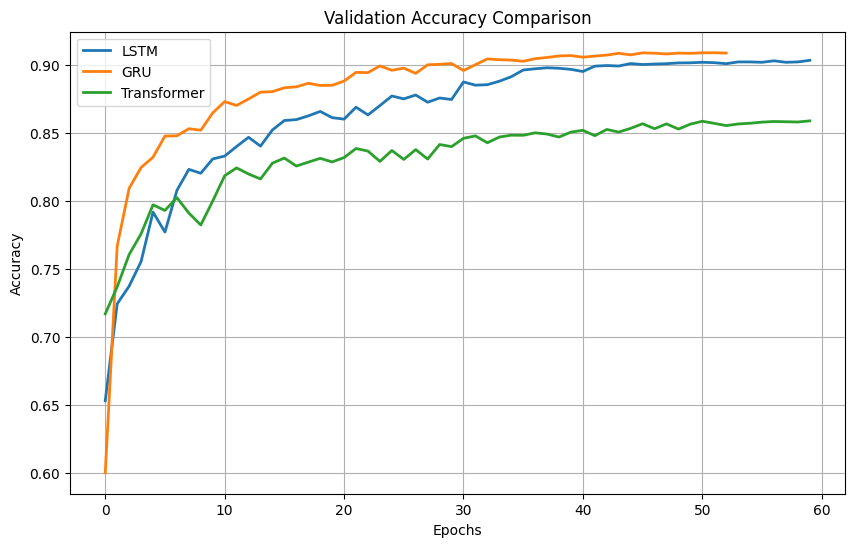

In [5]:
# %%
plt.figure(figsize=(10, 6))

plt.plot(lstm_h['val_accuracy'], label='LSTM', linewidth=2)
plt.plot(gru_h['val_accuracy'], label='GRU', linewidth=2)
plt.plot(trans_h['val_accuracy'], label='Transformer', linewidth=2)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig('../results/graphs/bonus_val_accuracy.png')
plt.show()

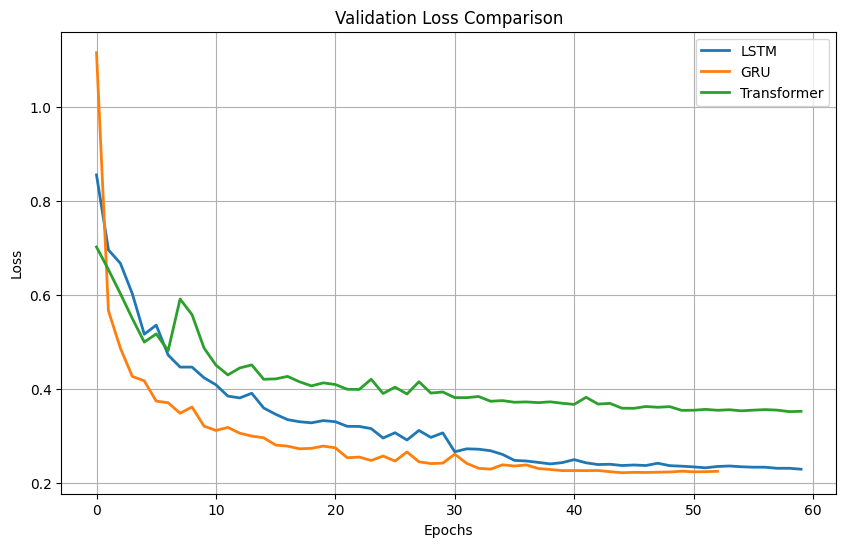

In [6]:
# %%
plt.figure(figsize=(10, 6))

plt.plot(lstm_h['val_loss'], label='LSTM', linewidth=2)
plt.plot(gru_h['val_loss'], label='GRU', linewidth=2)
plt.plot(trans_h['val_loss'], label='Transformer', linewidth=2)

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig('../results/graphs/bonus_val_loss.png')
plt.show()

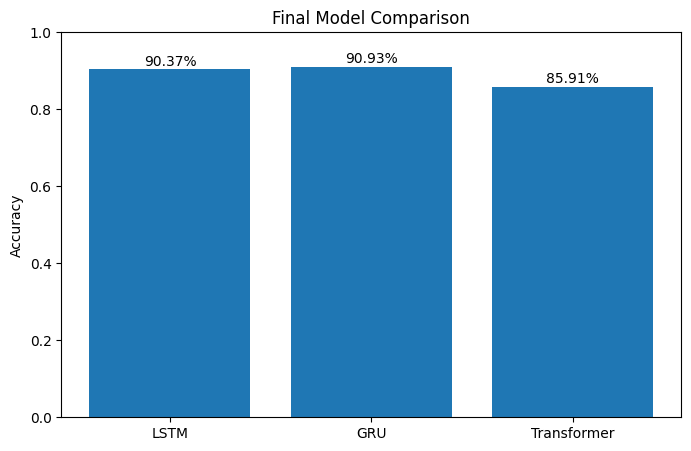

In [7]:
# %%
acc_results = {
    "LSTM": max(lstm_h['val_accuracy']),
    "GRU": max(gru_h['val_accuracy']),
    "Transformer": max(trans_h['val_accuracy'])
}

models = list(acc_results.keys())
accuracies = list(acc_results.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.01,
             f"{height*100:.2f}%",
             ha='center')

plt.title("Final Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.savefig('../results/graphs/bonus_final_comparison.png')
plt.show()

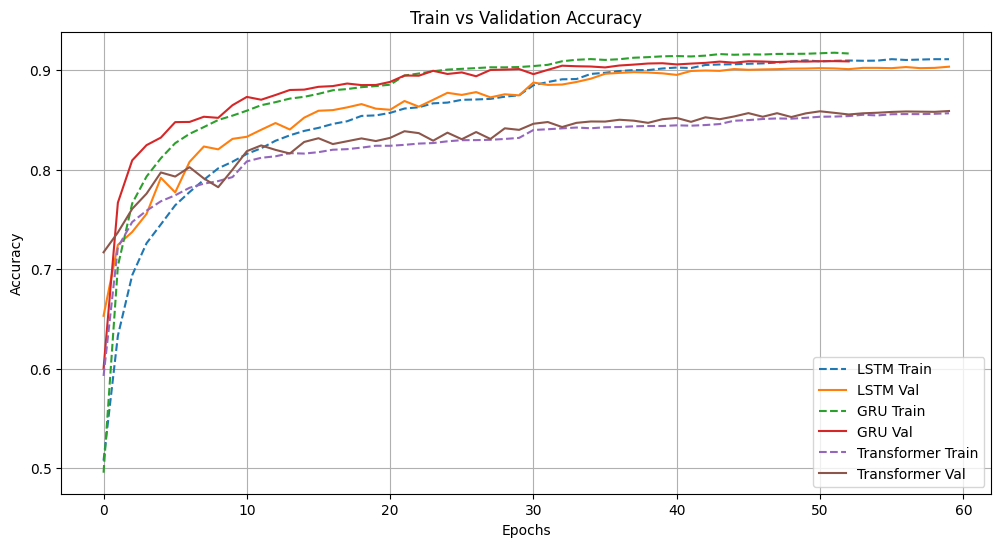

In [8]:
# %%
plt.figure(figsize=(12, 6))

plt.plot(lstm_h['accuracy'], '--', label='LSTM Train')
plt.plot(lstm_h['val_accuracy'], label='LSTM Val')

plt.plot(gru_h['accuracy'], '--', label='GRU Train')
plt.plot(gru_h['val_accuracy'], label='GRU Val')

plt.plot(trans_h['accuracy'], '--', label='Transformer Train')
plt.plot(trans_h['val_accuracy'], label='Transformer Val')

plt.title("Train vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig('../results/graphs/bonus_train_vs_val.png')
plt.show()

In [9]:
# %%
print("📊 MODEL PERFORMANCE SUMMARY\n")

for model, acc in acc_results.items():
    print(f"{model}: {acc*100:.2f}%")

best_model = max(acc_results, key=acc_results.get)

print("\n🏆 BEST MODEL:", best_model)

📊 MODEL PERFORMANCE SUMMARY

LSTM: 90.37%
GRU: 90.93%
Transformer: 85.91%

🏆 BEST MODEL: GRU


In [10]:
# %%
print("""
📌 FINAL INSIGHT:

- GRU performs best due to faster convergence and stability
- LSTM performs well but is slower
- Transformer requires more data to outperform RNN models

✔ GRU is the best choice for this dataset
""")


📌 FINAL INSIGHT:

- GRU performs best due to faster convergence and stability
- LSTM performs well but is slower
- Transformer requires more data to outperform RNN models

✔ GRU is the best choice for this dataset

